## Model Training   

#### 1.1 Import Data and Reguired Packages   

Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [2]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#modelling

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR   # for regression
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

import warnings

### Import the CSV Data as Pandas DataFrame

In [3]:
df = pd.read_csv('data/stud.csv')

In [4]:
# # add fake race/ethnicity column
# categories = ['group A', 'group B', 'group C', 'group D', 'group E']
# df['race_ethnicity'] = np.random.choice(categories, size=len(df))

# # Add lunch column
# df['lunch'] = np.random.choice(['standard', 'free/reduced'], size=len(df))

# # Add test preparation course
# df['test_preparation_course'] = np.random.choice(['none', 'completed'], size=len(df))

# df['lunch'] = np.where(df['math_score'] > 70, 'standard', 'free/reduced')
# print(df.head())

#### Show Top 5 Records

In [5]:
df.head()

,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
0,1,14,male,public,post graduate,3.1,84.3,yes,<15 min,yes,notes,42.7,55.4,57.0,53.1,e
1,2,18,female,public,graduate,3.7,87.8,yes,>60 min,no,textbook,57.6,68.8,64.8,61.3,d
2,3,17,female,private,post graduate,7.9,65.5,no,<15 min,no,notes,84.8,95.0,79.2,89.6,b
3,4,16,other,public,high school,1.1,58.1,no,15-30 min,no,notes,44.4,27.5,54.7,41.6,e
4,5,16,female,public,high school,1.3,61.0,yes,30-60 min,yes,group study,8.9,32.7,30.0,25.4,f


#### Preparing X and Y variables

In [6]:
x = df.drop('math_score', axis=1)
x.head()

,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,science_score,english_score,overall_score,final_grade
0,1,14,male,public,post graduate,3.1,84.3,yes,<15 min,yes,notes,55.4,57.0,53.1,e
1,2,18,female,public,graduate,3.7,87.8,yes,>60 min,no,textbook,68.8,64.8,61.3,d
2,3,17,female,private,post graduate,7.9,65.5,no,<15 min,no,notes,95.0,79.2,89.6,b
3,4,16,other,public,high school,1.1,58.1,no,15-30 min,no,notes,27.5,54.7,41.6,e
4,5,16,female,public,high school,1.3,61.0,yes,30-60 min,yes,group study,32.7,30.0,25.4,f


In [7]:
# print("Categories in 'gender' variable:    ",end="")
# print(df['gender'].unique())

# print("Categories in 'race/ethnicity' variable:  ",end=" ")
# print(df['race_ethnicity'].unique())

# print("Categories in 'parental level of education' variable: ",end=" ")
# print(df['parent_education'].unique())

# print("Categories in 'lunch' variable: ", end=" ")
# print(df['lunch'].unique())

# print("Categories in 'test preparation course' variable: ", end=" ")
# print(df['test_preparation_course'].unique())



In [8]:
y = df['math_score']
y.head()

0    42.7
1    57.6
2    84.8
3    44.4
4     8.9
Name: math_score, dtype: float64

In [9]:
# Create Column Transformer with 3 types of transformers

num_features = x.select_dtypes(exclude='object').columns
cat_features = x.select_dtypes(include='object').columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder",oh_transformer,cat_features),
        ("standardscaler", numeric_transformer,num_features)
    ]
)

C:\Users\shaikh\AppData\Local\Temp\ipykernel_9684\827878863.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = x.select_dtypes(include='object').columns


In [10]:
x = preprocessor.fit_transform(x)
x


array([[ 0.        ,  1.        ,  0.        , ..., -0.39796263,
        -0.32136682, -0.57608155],
       [ 1.        ,  0.        ,  0.        , ...,  0.24104213,
         0.05377246, -0.14294436],
       [ 1.        ,  0.        ,  0.        , ...,  1.4904395 ,
         0.7463373 ,  1.35190718],
       ...,
       [ 0.        ,  0.        ,  1.        , ..., -2.0717736 ,
        -1.32654772, -1.44235595],
       [ 0.        ,  1.        ,  0.        , ..., -1.40892538,
        -2.71167738, -1.57969213],
       [ 0.        ,  0.        ,  1.        , ..., -0.88913793,
        -2.26920541, -1.72231047]], shape=(25000, 38))

In [11]:
x.shape

(25000, 38)

In [12]:
# separate dataset into train and test

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)
x_train.shape, x_test.shape

((20000, 38), (5000, 38))

## Create an Evaluate Function to give all metrics after model Training

In [13]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2 = r2_score(true, predicted)
    return mae, rmse, r2

In [14]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(),
    "CatBoost Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}

model_list = []
r2_list = []

for name, model in models.items():

    model.fit(x_train, y_train)

    # Predictions
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    # Evaluation
    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    print(name)
    model_list.append(name)

    print("Model performance for Training set")
    print("- RMSE: {:.4f}".format(model_train_rmse))
    print("- MAE: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('--------------------------------------------------')

    print("Model performance for Test set")
    print("- RMSE: {:.4f}".format(model_test_rmse))
    print("- MAE: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))

    r2_list.append(model_test_r2)

    print('=' * 35)
    print()

Linear Regression
Model performance for Training set
- RMSE: 9.7478
- MAE: 7.8065
- R2 Score: 0.7819
--------------------------------------------------
Model performance for Test set
- RMSE: 9.5580
- MAE: 7.6256
- R2 Score: 0.7904

Lasso
Model performance for Training set
- RMSE: 9.8346
- MAE: 7.8912
- R2 Score: 0.7780
--------------------------------------------------
Model performance for Test set
- RMSE: 9.5986
- MAE: 7.6600
- R2 Score: 0.7886

Ridge
Model performance for Training set
- RMSE: 9.7478
- MAE: 7.8066
- R2 Score: 0.7819
--------------------------------------------------
Model performance for Test set
- RMSE: 9.5580
- MAE: 7.6257
- R2 Score: 0.7904

K-Neighbors Regressor
Model performance for Training set
- RMSE: 8.0183
- MAE: 6.1774
- R2 Score: 0.8525
--------------------------------------------------
Model performance for Test set
- RMSE: 10.5396
- MAE: 8.2537
- R2 Score: 0.7451

Decision Tree
Model performance for Training set
- RMSE: 0.0000
- MAE: 0.0000
- R2 Score: 1

#### Results

In [15]:
import pandas as pd
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name','r2_score']).sort_values(by=['r2_score'], ascending=False)

,Model Name,r2_score
5,Random Forest Regressor,0.881532
6,XGBRegressor,0.829878
7,CatBoost Regressor,0.817618
0,Linear Regression,0.790372
2,Ridge,0.790371
4,Decision Tree,0.790171
1,Lasso,0.788588
8,AdaBoost Regressor,0.784969
3,K-Neighbors Regressor,0.745105


#### Linear Regression

In [16]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(x_train, y_train)
y_pred = lin_model.predict(x_test)
score = r2_score(y_test, y_pred)*100
print(" Accuracy of the model is %.2f" %score)

 Accuracy of the model is 79.04


#### Plot y_pred and y_test

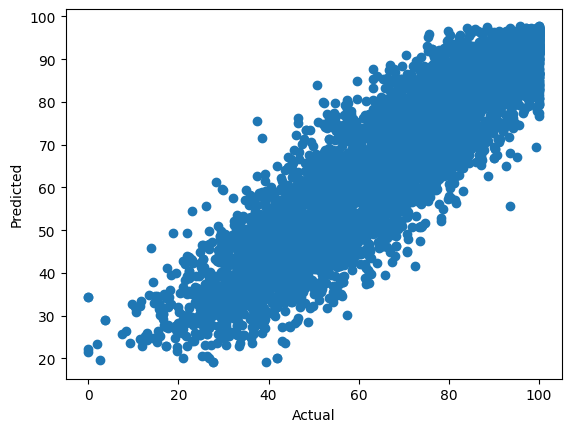

In [17]:
plt.scatter(y_test, y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

<Axes: xlabel='math_score'>

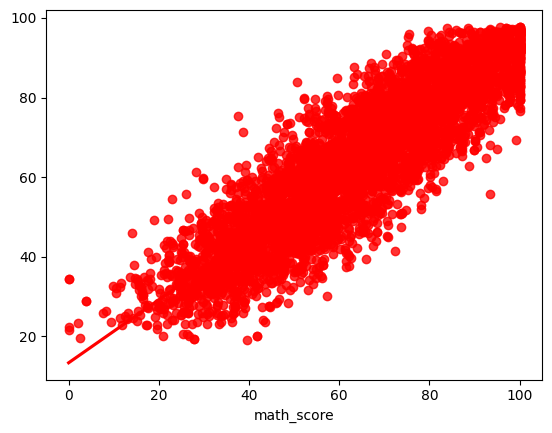

In [18]:
sns.regplot(x=y_test, y=y_pred, ci=None, color='red')

#### Difference between Actual and Predicted Values

In [20]:
pred_df = pd.DataFrame({'Actual Value': y_test,'Predicted Value':y_pred, 'Difference':y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
6868,71.0,86.089301,-15.089301
24016,41.1,45.841292,-4.741292
9668,73.2,67.197301,6.002699
13640,56.1,44.010041,12.089959
14018,49.9,36.957498,12.942502
...,...,...,...
8670,67.0,51.181203,15.818797
11839,56.0,48.612968,7.387032
4013,22.4,28.415169,-6.015169
21147,91.6,91.617322,-0.017322
